In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

from google.colab import files
uploaded = files.upload()

Saving Employee.csv to Employee.csv


In [5]:
import pandas as pd

df = pd.read_csv('Employee.csv')
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


# **Explore the Data**

In [6]:
# Check data types and basic info
df.info()

# Show unique values in each column and their count
for col in df.columns:
    print(f"Column: {col}")
    print("Unique Values:", df[col].unique())
    print("Count of Unique Values:", df[col].nunique())
    print("-" * 40)

# Statistical Summary
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB
Column: Company
Unique Values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Count of Unique Values: 6
----------------------------------------
Column: Age
Unique Values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Count of Unique Values: 29
----------------------------------------
Column: Salary
Unique Values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835

,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


# **Data Cleaning**

In [8]:
#Rename Columns (if needed)
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
df.head()

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [9]:
# Total missing values per column
print("Missing values:\n", df.isnull().sum())

Missing values:
 company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64


In [14]:
#Replace Age = 0 with NaN
df['age'] = df['age'].replace(0, np.nan)

In [13]:
#Remove Duplicate Rows
df = df.drop_duplicates()

In [15]:
# Fill Missing Values (mean for numeric, mode for categorical)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

<ipython-input-15-b5193d687c57>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
<ipython-input-15-b5193d687c57>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [18]:
#Outlier Detection (using IQR Method)

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 * IQR)]

# Example: remove outliers from 'salary'
if 'salary' in df.columns:
    df = remove_outliers_iqr(df, 'salary')

# **Data Analysis**

In [19]:
#Filter: Age > 40 and Salary < 5000
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]
print(filtered_df)

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


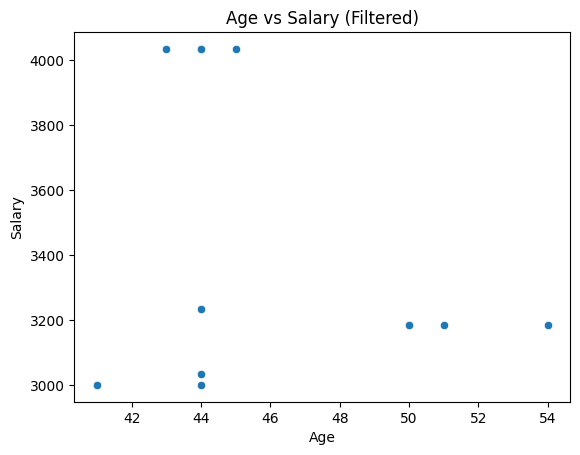

In [20]:
#Plot Age vs Salary
sns.scatterplot(data=filtered_df, x='age', y='salary')
plt.title("Age vs Salary (Filtered)")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

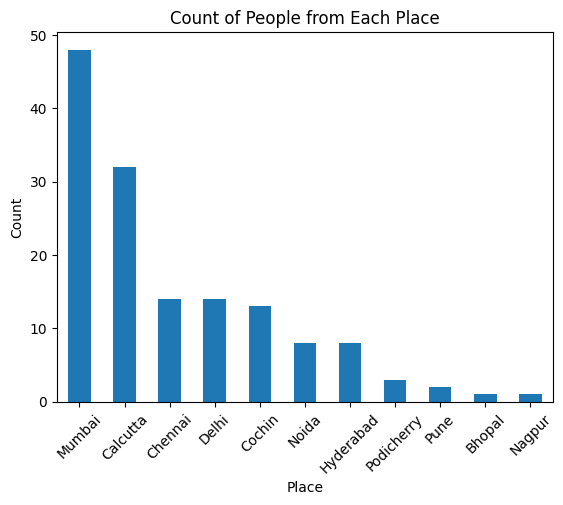

In [21]:
 # Count People from Each Place
if 'place' in df.columns:
    place_counts = df['place'].value_counts()
    place_counts.plot(kind='bar')
    plt.title("Count of People from Each Place")
    plt.xlabel("Place")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# **Data Encoding**

In [22]:
#Label Encoding (for binary categoricals)

label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() == 2:
        df[col] = label_enc.fit_transform(df[col])

In [23]:
# One-Hot Encoding (for multi-class categoricals)
df = pd.get_dummies(df, drop_first=True)

# **Feature Scaling**

In [24]:
#StandardScaler

scaler_std = StandardScaler()
scaled_std = scaler_std.fit_transform(df)

df_std = pd.DataFrame(scaled_std, columns=df.columns)
print("\nStandard Scaled Data:\n")
print(df_std.head())


Standard Scaled Data:

        age    salary    gender  company_Congnizant  company_Infosys  \
0 -1.484676 -0.100827 -0.534522           -0.118678        -0.652490   
1 -0.267174 -0.100827 -0.534522           -0.118678         1.532592   
2  0.341577 -1.243735 -0.534522           -0.118678        -0.652490   
3  0.950328 -0.947426 -0.534522           -0.118678         1.532592   
4 -1.119426 -0.524127 -0.534522           -0.118678        -0.652490   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                -0.118678     1.183216                          -0.118678   
1                -0.118678    -0.845154                          -0.118678   
2                -0.118678     1.183216                          -0.118678   
3                -0.118678    -0.845154                          -0.118678   
4                -0.118678     1.183216                          -0.118678   

   place_Calcutta  place_Chennai  place_Cochin  place_Delhi  place_Hyderab

In [25]:
#MinMaxScaler
scaler_mm = MinMaxScaler()
scaled_mm = scaler_mm.fit_transform(df)

df_mm = pd.DataFrame(scaled_mm, columns=df.columns)
print("\nMin-Max Scaled Data:\n")
print(df_mm.head())


Min-Max Scaled Data:

        age    salary  gender  company_Congnizant  company_Infosys  \
0  0.081081  0.445089     0.0                 0.0              0.0   
1  0.351351  0.445089     0.0                 0.0              1.0   
2  0.486486  0.137817     0.0                 0.0              0.0   
3  0.621622  0.217480     0.0                 0.0              1.0   
4  0.162162  0.331285     0.0                 0.0              0.0   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                      0.0          1.0                                0.0   
1                      0.0          0.0                                0.0   
2                      0.0          1.0                                0.0   
3                      0.0          0.0                                0.0   
4                      0.0          1.0                                0.0   

   place_Calcutta  place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  \
0      